In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from scipy import stats

In [23]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
os.chdir(r"C:\Users\bianca\Desktop\TRAIL_RUNNING_PREDICTOR\trail-running-time-predictor\backend\notebooks")
os.getcwd()

'C:\\Users\\bianca\\Desktop\\TRAIL_RUNNING_PREDICTOR\\trail-running-time-predictor\\backend\\notebooks'

In [24]:
#Load data
df = pd.read_parquet("segments_training_features_new.parquet", engine="pyarrow")
print(df.shape)
print(df.head(10))

(2472, 18)
   segment_distance_m  segment_time_sec  segment_pace_mps  elevation_gain_m  \
0               119.3              31.0            3.8484               0.0   
1               808.8             418.0            1.9349              80.4   
2               811.4             933.0            0.8697             208.6   
3               810.8             763.0            1.0626             141.8   
4               784.6             832.0            0.9430             175.2   
5               791.0             871.0            0.9082             178.8   
6               787.2             987.0            0.7976             135.2   
7               829.7             425.0            1.9522             101.6   
8               826.9             931.0            0.8882             234.0   
9                83.3              43.0            1.9372               0.0   

   elevation_loss_m  avg_gradient  std_gradient  max_uphill_gradient  \
0               3.6         0.030        0.0349

In [44]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

segment_distance_m       0
segment_time_sec         0
activity_name            0
activity_id              0
segment_energy_cost      0
cumulative_elevation     0
downhill_cost            0
uphill_cost              0
intensity_level          0
avg_elevation            0
max_downhill_gradient    0
max_uphill_gradient      0
std_gradient             0
avg_gradient             0
elevation_loss_m         0
elevation_gain_m         0
segment_pace_mps         0
start_date               0
dtype: int64


In [4]:
df.describe()

,segment_distance_m,segment_time_sec,segment_pace_mps,elevation_gain_m,elevation_loss_m,avg_gradient,std_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,segment_energy_cost,activity_id
count,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2.642000e+03
mean,315.995079,225.276949,1.891496,19.359765,18.030999,0.087406,0.054395,0.103322,0.095088,894.372369,1.152157,272.981340,193.417903,642.974451,1436.872027,1.266766e+10
std,262.239666,281.726051,0.870927,42.341840,37.929640,0.072115,0.039198,0.176913,0.139669,742.105196,0.722032,479.942543,310.849237,511.716430,1828.030765,2.720411e+09
min,50.000000,30.000000,0.151700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,115.900000,0.000000,0.000000,0.000000,0.000000,93.585000,8.940729e+09
25%,102.975000,56.000000,1.184100,0.000000,0.000000,0.029000,0.026600,0.000000,0.000000,220.575000,1.000000,0.000000,0.000000,258.850000,370.590250,9.563757e+09
50%,198.050000,122.500000,1.827550,0.100000,0.000000,0.072000,0.048000,0.000000,0.000000,476.850000,1.000000,52.500000,0.000000,512.200000,706.674000,1.222812e+10
75%,489.150000,283.750000,2.612325,11.600000,13.150000,0.128000,0.070975,0.169500,0.167000,1437.350000,2.000000,270.675000,234.225000,968.000000,1609.211000,1.528911e+10
max,997.000000,2959.000000,5.596400,318.900000,271.800000,0.493000,0.598000,3.500000,0.954000,2544.400000,2.000000,2801.600000,1443.400000,2674.400000,13312.120000,1.756427e+10


#CHECKING FOR OUTLIER SEGMENTS : short segmets with time more than 20 minutes and pace <0.1 (this means stationary and pauses)

In [5]:
df[(df['segment_time_sec'] >= 1200) | (df['segment_pace_mps'] <= 0.15)]

,segment_distance_m,segment_time_sec,segment_pace_mps,elevation_gain_m,elevation_loss_m,avg_gradient,std_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,segment_energy_cost,activity_id,activity_name,start_date
100,924.7,1546.0,0.5981,229.0,0.0,0.248,0.0756,0.428,0.000,354.0,1,2298.7,0.0,340.0,9840.150,17171419980,Șiria Trail Run,2026-01-25T09:55:45+00:00
292,982.3,1522.0,0.6454,245.4,0.0,0.250,0.1200,0.644,0.000,1714.7,0,2454.7,0.0,633.8,10529.119,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
293,926.5,1255.0,0.7382,155.0,0.0,0.167,0.0644,0.333,0.000,1913.9,0,1856.5,0.0,793.4,7367.465,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
307,623.4,1733.0,0.3597,206.6,0.0,0.331,0.3708,1.562,0.000,2380.9,0,1863.0,0.0,1323.8,8619.205,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
309,881.3,1718.0,0.5130,0.0,256.8,0.291,0.1984,0.000,0.833,2354.6,0,0.0,1394.9,1342.0,2092.911,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
412,908.0,1326.0,0.6848,160.8,0.0,0.177,0.0961,0.387,0.000,1532.4,1,1872.8,0.0,532.6,7501.928,15728925763,Tarcu Trail Run 🏃‍♀️⛰️,2025-09-07T08:29:49+00:00
588,679.9,1301.0,0.5226,159.4,0.0,0.234,0.1428,0.592,0.000,1968.7,0,1636.3,0.0,722.8,6919.227,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
589,679.2,1612.0,0.4213,212.6,0.0,0.313,0.1428,0.717,0.000,2161.1,0,1954.8,0.0,940.0,8888.944,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
622,650.1,2959.0,0.2197,89.4,0.0,0.138,0.0539,0.280,0.000,1508.0,1,1186.5,0.0,343.2,4577.570,15430495730,Cortina D'Ampezzo Run,2025-08-12T07:18:22+00:00
771,970.3,1217.0,0.7973,257.4,0.0,0.265,0.1012,0.511,0.000,1357.2,2,2514.7,0.0,634.0,10941.551,14794884942,Retezat Sky Race - Cursa Buta⛰️🏃‍♀️,2025-06-14T05:59:51+00:00


Check for very steep segments - technical terrain/ scrambling

In [7]:
df[df["avg_gradient"]> 0.3]

,segment_distance_m,segment_time_sec,segment_pace_mps,elevation_gain_m,elevation_loss_m,avg_gradient,std_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,segment_energy_cost,activity_id,activity_name,start_date
307,623.4,1733.0,0.3597,206.6,0.0,0.331,0.3708,1.562,0.000,2380.9,0,1863.0,0.0,1323.8,8619.205,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
311,413.0,741.0,0.5574,0.0,163.4,0.396,0.1558,0.000,0.883,2148.7,0,0.0,739.8,1352.6,1471.391,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
460,822.8,1157.0,0.7111,264.4,0.0,0.321,0.1680,0.788,0.000,1775.7,2,2409.2,0.0,756.2,11040.875,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
471,187.6,263.0,0.7133,57.0,0.0,0.304,0.1914,0.790,0.000,1892.4,2,529.6,0.0,884.8,2387.756,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
484,368.8,236.0,1.5627,0.0,117.8,0.319,0.1327,0.000,0.592,1879.6,2,0.0,604.4,997.6,985.861,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
517,529.7,396.0,1.3376,0.0,170.8,0.322,0.0776,0.000,0.481,1717.8,2,0.0,871.3,2068.0,1434.179,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
589,679.2,1612.0,0.4213,212.6,0.0,0.313,0.1428,0.717,0.000,2161.1,0,1954.8,0.0,940.0,8888.944,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
590,93.1,510.0,0.1825,0.0,33.2,0.357,0.1279,0.000,0.569,2262.7,0,0.0,159.5,950.6,289.528,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
794,692.1,642.0,1.0780,0.0,246.2,0.356,0.1163,0.000,0.619,1822.4,2,0.0,1184.5,1322.6,2145.074,14794884942,Retezat Sky Race - Cursa Buta⛰️🏃‍♀️,2025-06-14T05:59:51+00:00
902,355.6,791.0,0.4496,108.0,0.0,0.304,0.1081,0.492,0.000,183.2,1,1003.6,0.0,108.8,4524.306,14222236090,Alergare Soimos 🌞🥵,2025-04-19T09:02:09+00:00


In [8]:
df["segment_pace_mps"].describe()

count    2642.000000
mean        1.891496
std         0.870927
min         0.151700
25%         1.184100
50%         1.827550
75%         2.612325
max         5.596400
Name: segment_pace_mps, dtype: float64

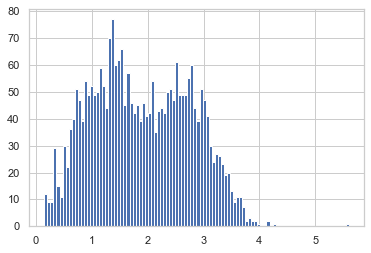

In [48]:
df["segment_pace_mps"].hist(bins=100)

Segments that have a higher pace => probably lower slope descents, or segment sprints => the fastest

In [55]:
df[df["segment_pace_mps"]>4]

,segment_distance_m,segment_time_sec,segment_pace_mps,elevation_gain_m,elevation_loss_m,avg_gradient,std_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,segment_energy_cost,activity_id,activity_name,start_date
203,518.2,129.0,4.0171,1.0,0.0,0.002,0.0089,0.000,0.000,244.3,2,524.2,0.0,2.0,1885.109,16176960343,Alergand la Padure - Resita,2025-10-18T07:01:01+00:00
645,127.1,30.0,4.2367,0.0,5.4,0.042,0.0298,0.000,0.105,190.8,1,0.0,137.9,122.2,363.289,15289114294,Hill Repeats 🏃‍♀️,2025-07-30T16:33:41+00:00
1713,395.1,95.0,4.1589,0.0,56.0,0.142,0.0657,0.000,0.290,201.4,1,0.0,507.1,84.8,738.207,11282124831,Hill Repeats 🏃‍♀️,2024-04-28T09:33:58+00:00
1971,313.4,56.0,5.5964,2.8,0.0,0.009,0.0295,0.076,0.000,203.3,1,330.2,0.0,94.0,1183.989,9563756857,Herneacova Hill Repeats,2023-08-01T16:16:26+00:00
2447,489.0,118.0,4.1441,0.0,57.5,0.118,0.0569,0.000,0.241,197.4,1,0.0,604.0,79.4,982.071,9067983184,Herneacova Hill Run,2023-05-14T06:50:34+00:00


In [21]:
df[df['segment_time_sec'] >= 1200]

,segment_distance_m,segment_time_sec,segment_pace_mps,elevation_gain_m,elevation_loss_m,avg_gradient,std_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,segment_energy_cost,activity_id,activity_name,start_date
100,924.7,1546.0,0.5981,229.0,0.0,0.248,0.0756,0.428,0.000,354.0,1,2298.7,0.0,340.0,9840.150,17171419980,Șiria Trail Run,2026-01-25T09:55:45+00:00
292,982.3,1522.0,0.6454,245.4,0.0,0.250,0.1200,0.644,0.000,1714.7,0,2454.7,0.0,633.8,10529.119,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
293,926.5,1255.0,0.7382,155.0,0.0,0.167,0.0644,0.333,0.000,1913.9,0,1856.5,0.0,793.4,7367.465,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
306,623.4,1733.0,0.3597,206.6,0.0,0.331,0.3708,1.562,0.000,2380.9,0,1863.0,0.0,1323.8,8619.205,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
307,881.3,1718.0,0.5130,0.0,256.8,0.291,0.1984,0.000,0.833,2354.6,0,0.0,1394.9,1342.0,2092.911,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
410,908.0,1326.0,0.6848,160.8,0.0,0.177,0.0961,0.387,0.000,1532.4,1,1872.8,0.0,532.6,7501.928,15728925763,Tarcu Trail Run 🏃‍♀️⛰️,2025-09-07T08:29:49+00:00
418,146.4,1484.0,0.0987,0.0,12.6,0.086,0.0633,0.000,0.278,2195.9,1,0.0,171.6,1140.6,335.239,15728925763,Tarcu Trail Run 🏃‍♀️⛰️,2025-09-07T08:29:49+00:00
582,679.9,1301.0,0.5226,159.4,0.0,0.234,0.1428,0.592,0.000,1968.7,0,1636.3,0.0,722.8,6919.227,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
583,679.2,1612.0,0.4213,212.6,0.0,0.313,0.1428,0.717,0.000,2161.1,0,1954.8,0.0,940.0,8888.944,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
616,650.1,2959.0,0.2197,89.4,0.0,0.138,0.0539,0.280,0.000,1508.0,1,1186.5,0.0,343.2,4577.570,15430495730,Cortina D'Ampezzo Run,2025-08-12T07:18:22+00:00


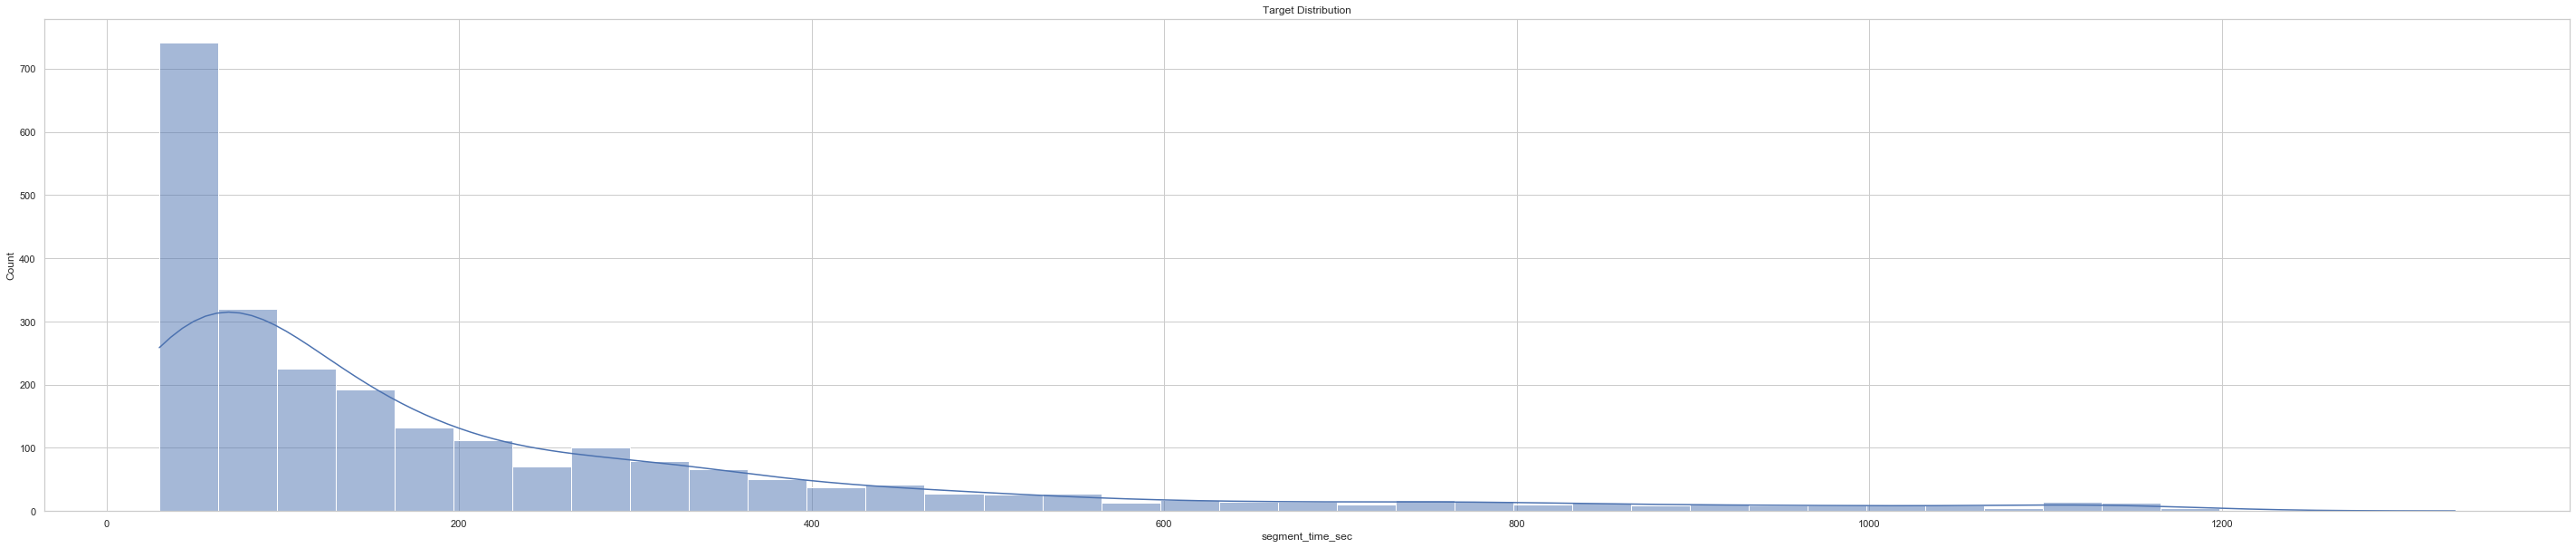

Skewness: 2.02703910626556


In [25]:
TARGET = "segment_time_sec"

#DISTRIBUTION OF TARGET VARIABLE
plt.figure(figsize=(50,10))
sns.histplot(df[TARGET], kde=True)
plt.title("Target Distribution")
plt.show()
print("Skewness:", stats.skew(df[TARGET]))

In [31]:
df[(df["avg_gradient"]>0.3) ]

,segment_distance_m,segment_time_sec,segment_pace_mps,elevation_gain_m,elevation_loss_m,avg_gradient,std_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,segment_energy_cost,activity_id,activity_name,start_date
306,623.4,935.10,0.6667,206.6,0.0,0.331,0.3708,1.562,0.000,2380.9,0,1863.0,0.0,1323.8,8619.205,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
309,413.0,741.00,0.5574,0.0,163.4,0.396,0.1558,0.000,0.883,2148.7,0,0.0,739.8,1352.6,1471.391,15965762457,Retezat Run ⛰️🏃‍♀️,2025-09-28T07:33:56+00:00
458,822.8,1157.00,0.7111,264.4,0.0,0.321,0.1680,0.788,0.000,1775.7,2,2409.2,0.0,756.2,11040.875,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
469,187.6,263.00,0.7133,57.0,0.0,0.304,0.1914,0.790,0.000,1892.4,2,529.6,0.0,884.8,2387.756,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
482,368.8,236.00,1.5627,0.0,117.8,0.319,0.1327,0.000,0.592,1879.6,2,0.0,604.4,997.6,985.861,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
515,529.7,396.00,1.3376,0.0,170.8,0.322,0.0776,0.000,0.481,1717.8,2,0.0,871.3,2068.0,1434.179,15557128586,Oslea Run - Traseu Paltina,2025-08-23T05:58:35+00:00
583,679.2,1018.80,0.6667,212.6,0.0,0.313,0.1428,0.717,0.000,2161.1,0,1954.8,0.0,940.0,8888.944,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
584,93.1,510.00,0.1825,0.0,33.2,0.357,0.1279,0.000,0.569,2262.7,0,0.0,159.5,950.6,289.528,15445077170,Lago di Sorapis,2025-08-13T07:50:00+00:00
783,692.1,642.00,1.0780,0.0,246.2,0.356,0.1163,0.000,0.619,1822.4,2,0.0,1184.5,1322.6,2145.074,14794884942,Retezat Sky Race - Cursa Buta⛰️🏃‍♀️,2025-06-14T05:59:51+00:00
891,355.6,791.00,0.4496,108.0,0.0,0.304,0.1081,0.492,0.000,183.2,1,1003.6,0.0,108.8,4524.306,14222236090,Alergare Soimos 🌞🥵,2025-04-19T09:02:09+00:00


# FEATURE TYPING

In [53]:
numeric_cols = df.select_dtypes(include = np.number).columns.tolist()
numeric_cols.remove(TARGET)

categorical_cols = df.select_dtypes(exclude = np.number).columns.tolist()

print("Numeric: ", numeric_cols)
print("Categorical: ", categorical_cols)

Numeric:  ['segment_distance_m', 'segment_pace_mps', 'elevation_gain_m', 'elevation_loss_m', 'avg_gradient', 'std_gradient', 'max_uphill_gradient', 'max_downhill_gradient', 'avg_elevation', 'intensity_level', 'uphill_cost', 'downhill_cost', 'cumulative_elevation', 'segment_energy_cost', 'activity_id']
Categorical:  ['activity_name', 'start_date']


We have mostly numerical features(the ones that we are using for training the model)

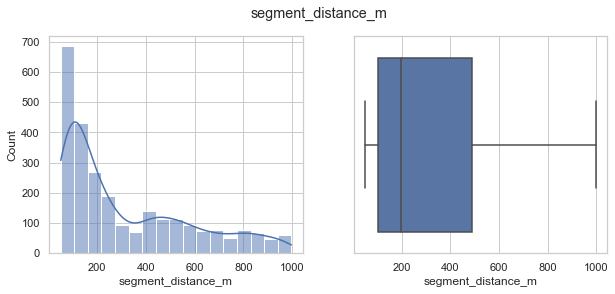

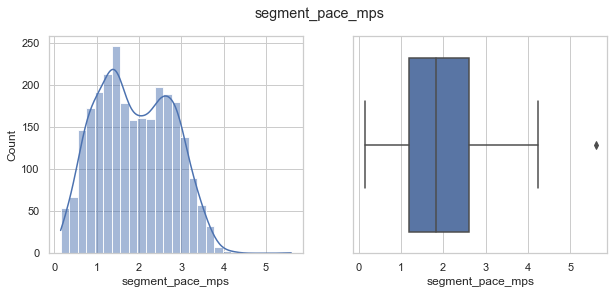

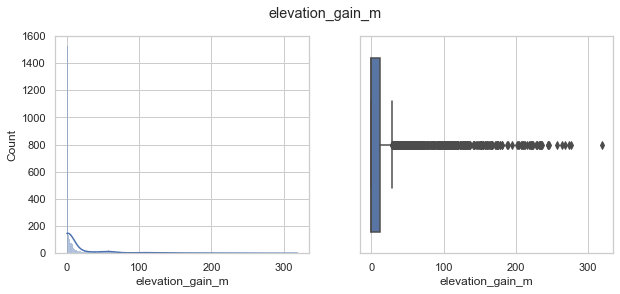

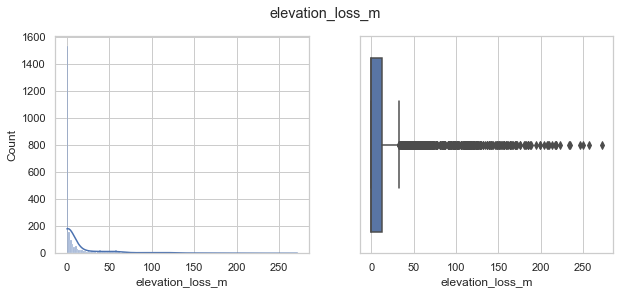

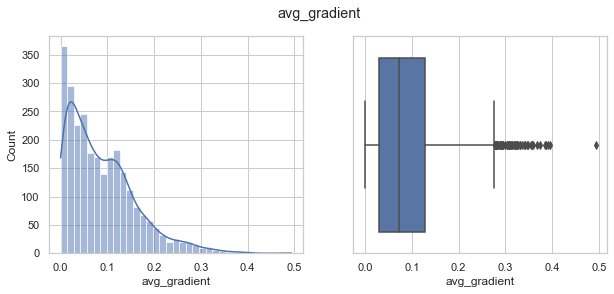

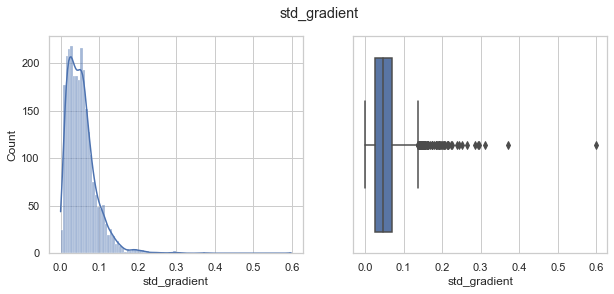

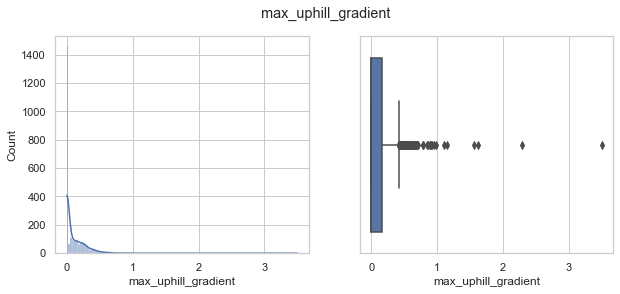

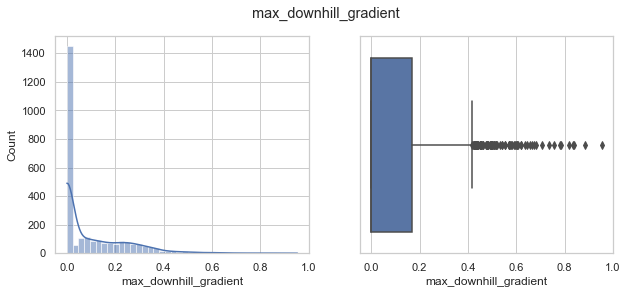

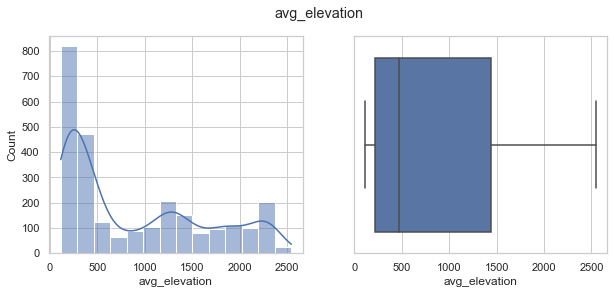

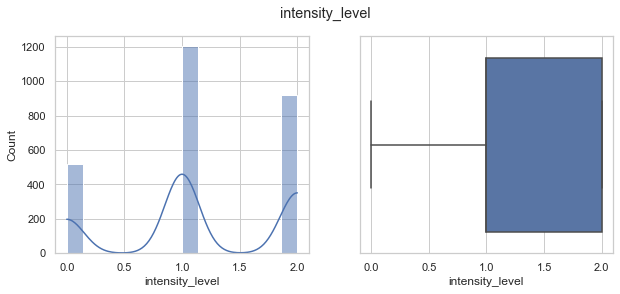

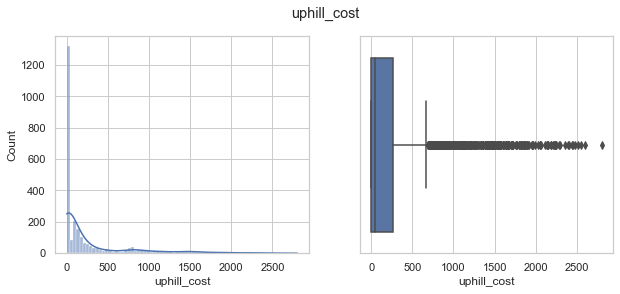

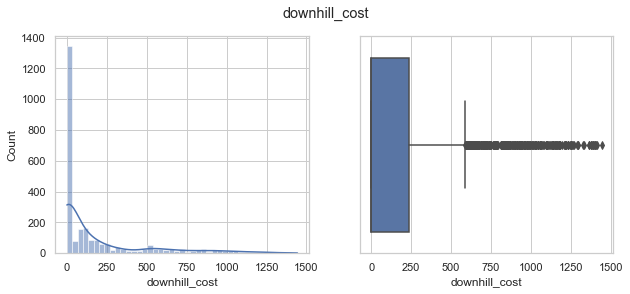

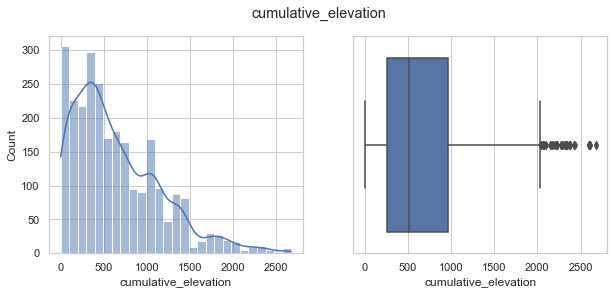

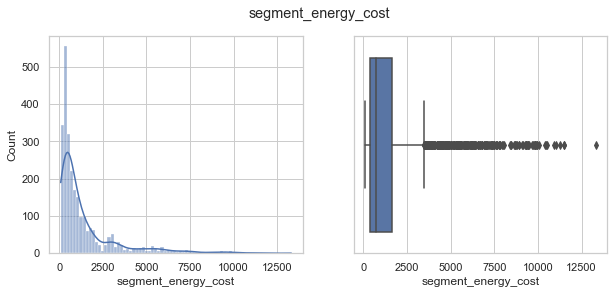

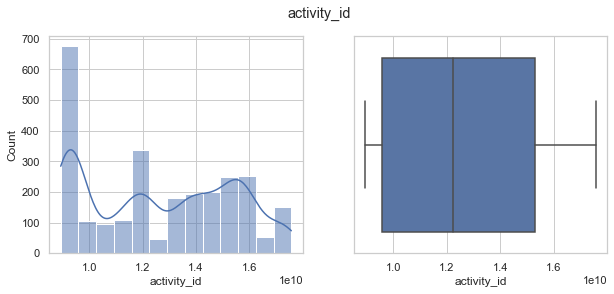

In [54]:
for col in numeric_cols:
    fig,ax = plt.subplots(1, 2 , figsize=(10,4)) 
    sns.histplot(df[col], kde = True, ax=ax[0])
    sns.boxplot(x=df[col], ax=ax[1])
    fig.suptitle(col)
    plt.show()

# BYVARIATE ANALYSIS (FEATURE-TARGET - LINIAR/ NON LINIAR)

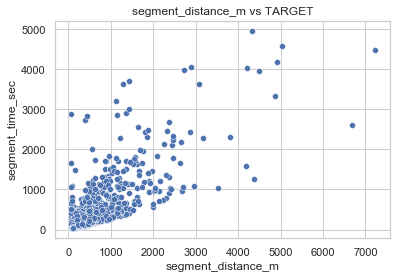

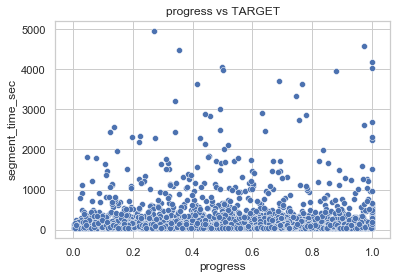

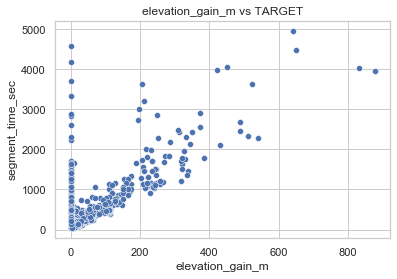

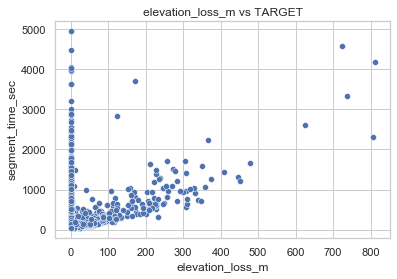

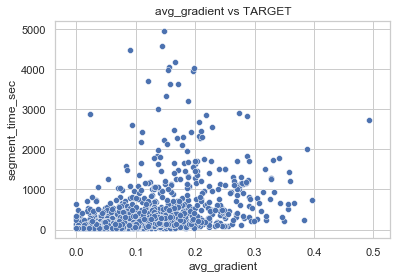

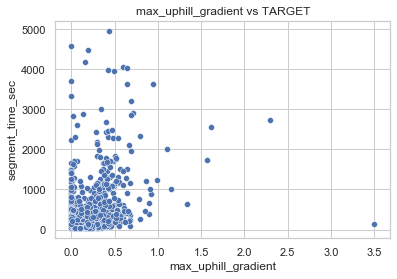

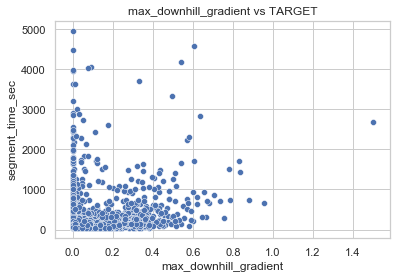

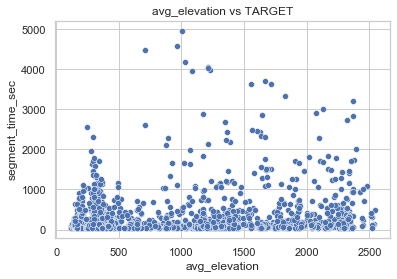

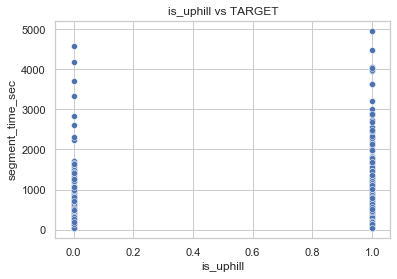

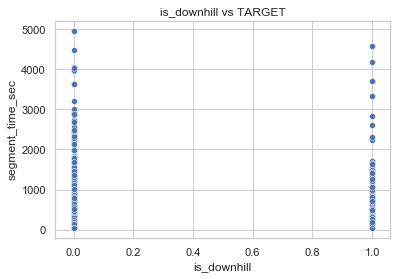

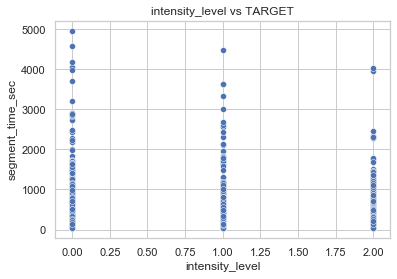

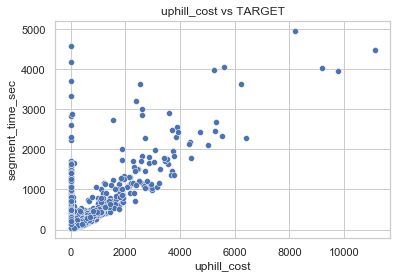

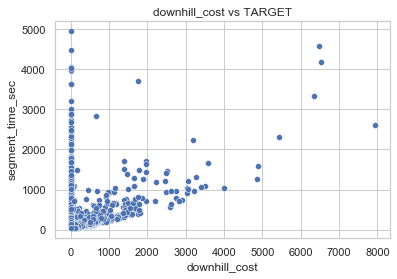

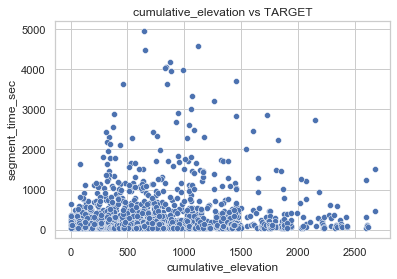

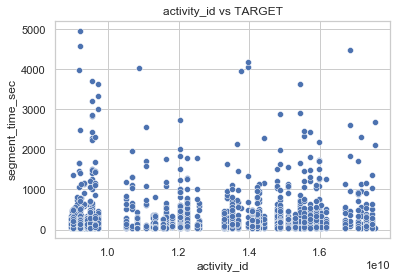

In [19]:
for col in numeric_cols:
    sns.scatterplot(x=df[col], y=df[TARGET])
    plt.title(f"{col} vs TARGET")
    plt.show()

In [20]:
df[df['segment_distance_m'] > 5000]

,segment_distance_m,segment_time_sec,progress,elevation_gain_m,elevation_loss_m,avg_gradient,max_uphill_gradient,max_downhill_gradient,avg_elevation,is_uphill,is_downhill,intensity_level,uphill_cost,downhill_cost,cumulative_elevation,activity_id,activity_name,start_date
900,7224.4,4482.0,0.353,650.4,0.0,0.090,0.187,0.000,706.5,1,0,1,11126.8,0.0,653.6,16862300380,Alergare Pades ⛰️🏃‍♀️❄️,2025-12-28T07:31:31+00:00
907,6687.1,2608.0,0.973,0.0,624.2,0.093,0.065,0.178,707.1,0,1,1,0.0,7935.5,1038.6,16862300380,Alergare Pades ⛰️🏃‍♀️❄️,2025-12-28T07:31:31+00:00
2375,5023.8,4586.0,0.974,0.0,724.9,0.144,0.000,0.605,968.0,0,1,0,0.0,6473.6,1116.5,9193905540,Trail running Camping Scorila - Muntele mic,2023-06-03T06:32:17+00:00


# CORRELATION WITH TARGET

In [33]:
corr_with_target = df[numeric_cols + [TARGET]].corr()[TARGET].sort_values(ascending=False)
print(corr_with_target)

total_time_sec                1.000000
elevation_gain_m              0.846497
elevation_loss_m              0.844627
uphill_distance_km            0.746421
total_distance_km             0.742484
downhill_distance_km          0.731008
average_elevation             0.693798
num_points                    0.653893
average_downhill_slope20m     0.432609
average_downhill_slope100m    0.382947
flat_distance_km              0.348327
average_uphill_slope20m       0.304743
average_uphill_slope100m      0.272923
steep_ratio_20                0.230989
activity_id                   0.073372
elevation_gain_last_30d       0.054175
is_race                      -0.038902
Name: total_time_sec, dtype: float64


# Multicollinearity

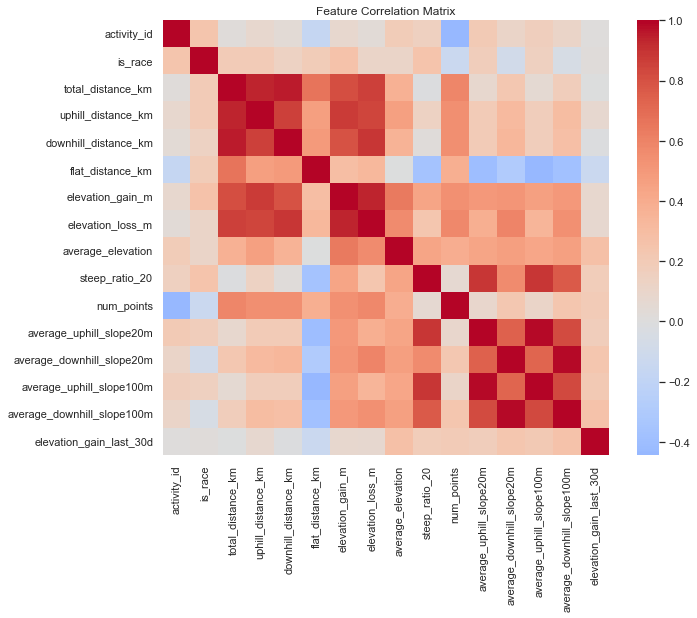

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()